
## 2. Clasificación — Diagnóstico de cáncer de mama (`breast-cancer.csv`)
### Algoritmo: Árbol de Decisión (`DecisionTreeClassifier`)

**Justificación del algoritmo:** El objetivo es clasificar cada tumor como **Maligno (M)** o **Benigno (B)**
a partir de 30 características numéricas calculadas sobre imágenes de núcleos celulares, lo que corresponde
a Análisis supervisado: los
algoritmos de clasificación, son aquellos donde el resultado a predecir es un atributo categórico"*. Se
eligió un **Árbol de Decisión** porque:
- Es uno de los algoritmos de clasificación mencionados en la  clase, y
  se describe como un modelo que, dado un conjunto de datos, fabrica diagramas de
  construcción lógica que sirven para representar y categorizar una serie de condiciones que ocurren de
  manera sucesiva.
- Es un modelo interpretable: permite visualizar exactamente qué variables (por ejemplo `radius_mean`,
  `concave points_mean`) y qué umbrales se usan para decidir el diagnóstico, lo cual es muy valioso en un
  contexto médico donde se requiere explicabilidad.
- No requiere escalar los datos ni asumir una distribución particular de las variables.
- El propio contenido de la evaluación solicita graficar el árbol completo cuando se use este algoritmo, y
  es el algoritmo practicado en el notebook de clase *Grid search-arbol decisiones*.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score)

%matplotlib inline
sns.set_style('whitegrid')


### Paso 1. Carga y exploración de los datos

In [2]:
DATA_DIR = os.path.join('..', '..', 'Conjunto de datos para 2a. evaluación')
datos = pd.read_csv(os.path.join(DATA_DIR, 'breast-cancer.csv'))
datos = datos.drop(columns=['id'])
datos.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
datos.describe()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


diagnosis
B    357
M    212
Name: count, dtype: int64


C:\Users\Yosue\AppData\Local\Temp\ipykernel_29740\1628143835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=datos, palette=['#4C72B0', '#DD8452'])


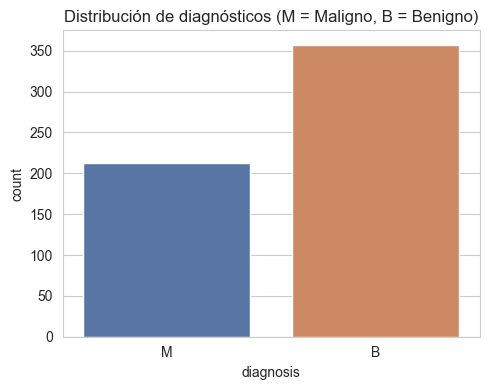

In [4]:
print(datos['diagnosis'].value_counts())
plt.figure(figsize=(5, 4))
sns.countplot(x='diagnosis', data=datos, palette=['#4C72B0', '#DD8452'])
plt.title('Distribución de diagnósticos (M = Maligno, B = Benigno)')
plt.tight_layout()
plt.savefig('grafica_distribucion_diagnostico.png', dpi=120)
plt.show()


### Paso 2. Codificación de la variable objetivo y correlación entre variables

In [5]:
le = LabelEncoder()
datos['diagnosis_cod'] = le.fit_transform(datos['diagnosis'])  # B=0, M=1
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'B': np.int64(0), 'M': np.int64(1)}

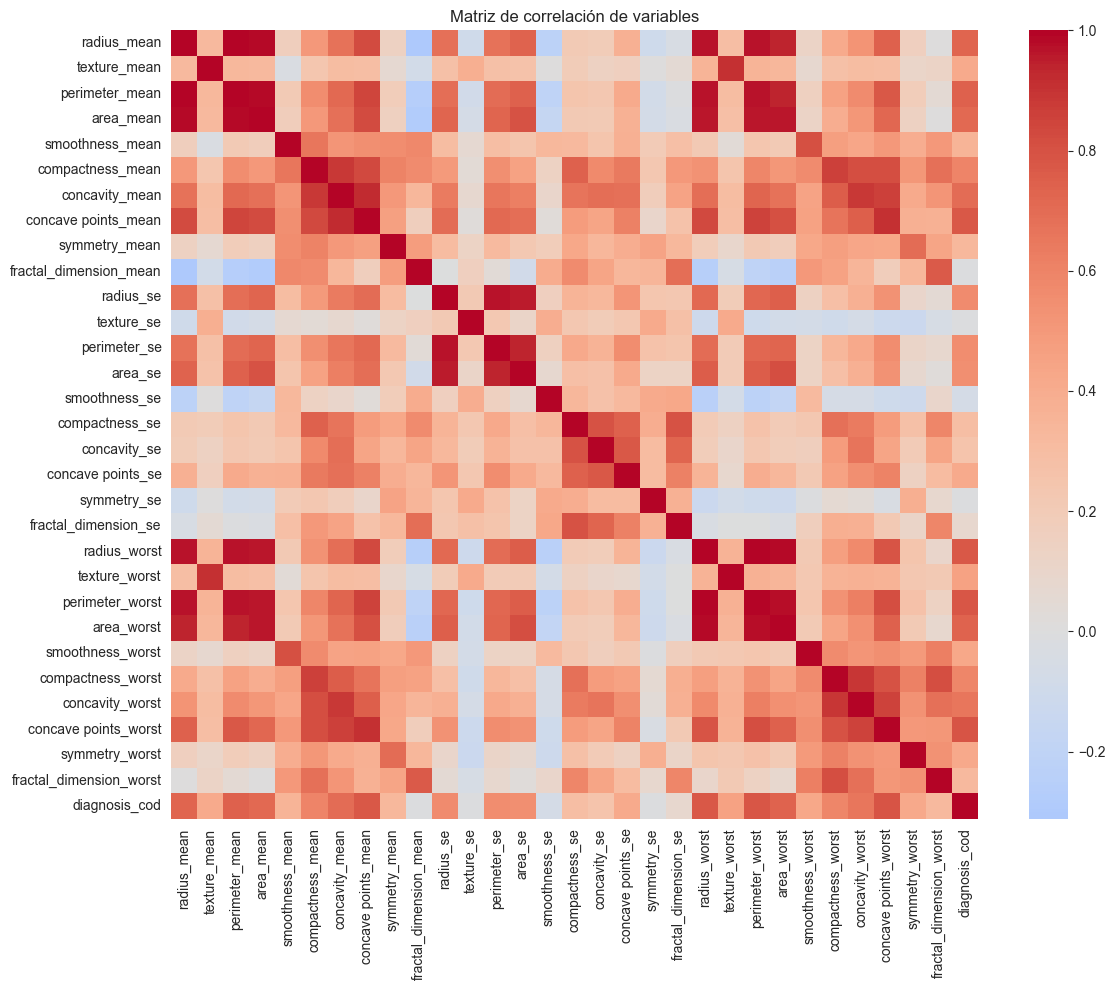

In [6]:
plt.figure(figsize=(12, 10))
corr = datos.drop(columns=['diagnosis']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlación de variables')
plt.tight_layout()
plt.savefig('grafica_correlacion_breastcancer.png', dpi=120)
plt.show()


### Paso 3. División de datos y entrenamiento del modelo base

In [7]:
X = datos.drop(columns=['diagnosis', 'diagnosis_cod']).values
y = datos['diagnosis_cod'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
print(X_train.shape, X_test.shape)


(455, 30) (114, 30)


In [8]:
modelo = DecisionTreeClassifier(random_state=1)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
print('Exactitud (accuracy):', accuracy_score(y_test, predicciones))


Exactitud (accuracy): 0.9298245614035088


### Paso 4. Evaluación del modelo base

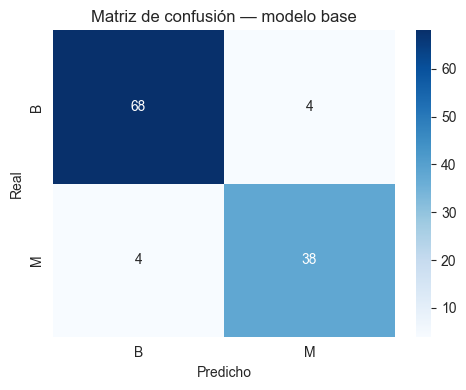

              precision    recall  f1-score   support

           B       0.94      0.94      0.94        72
           M       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [9]:
cm = confusion_matrix(y_test, predicciones)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión — modelo base')
plt.tight_layout()
plt.savefig('grafica_matriz_confusion_base.png', dpi=120)
plt.show()

print(classification_report(y_test, predicciones, target_names=['B', 'M']))


### Paso 5. Gráfica del árbol de decisión completo (modelo base)

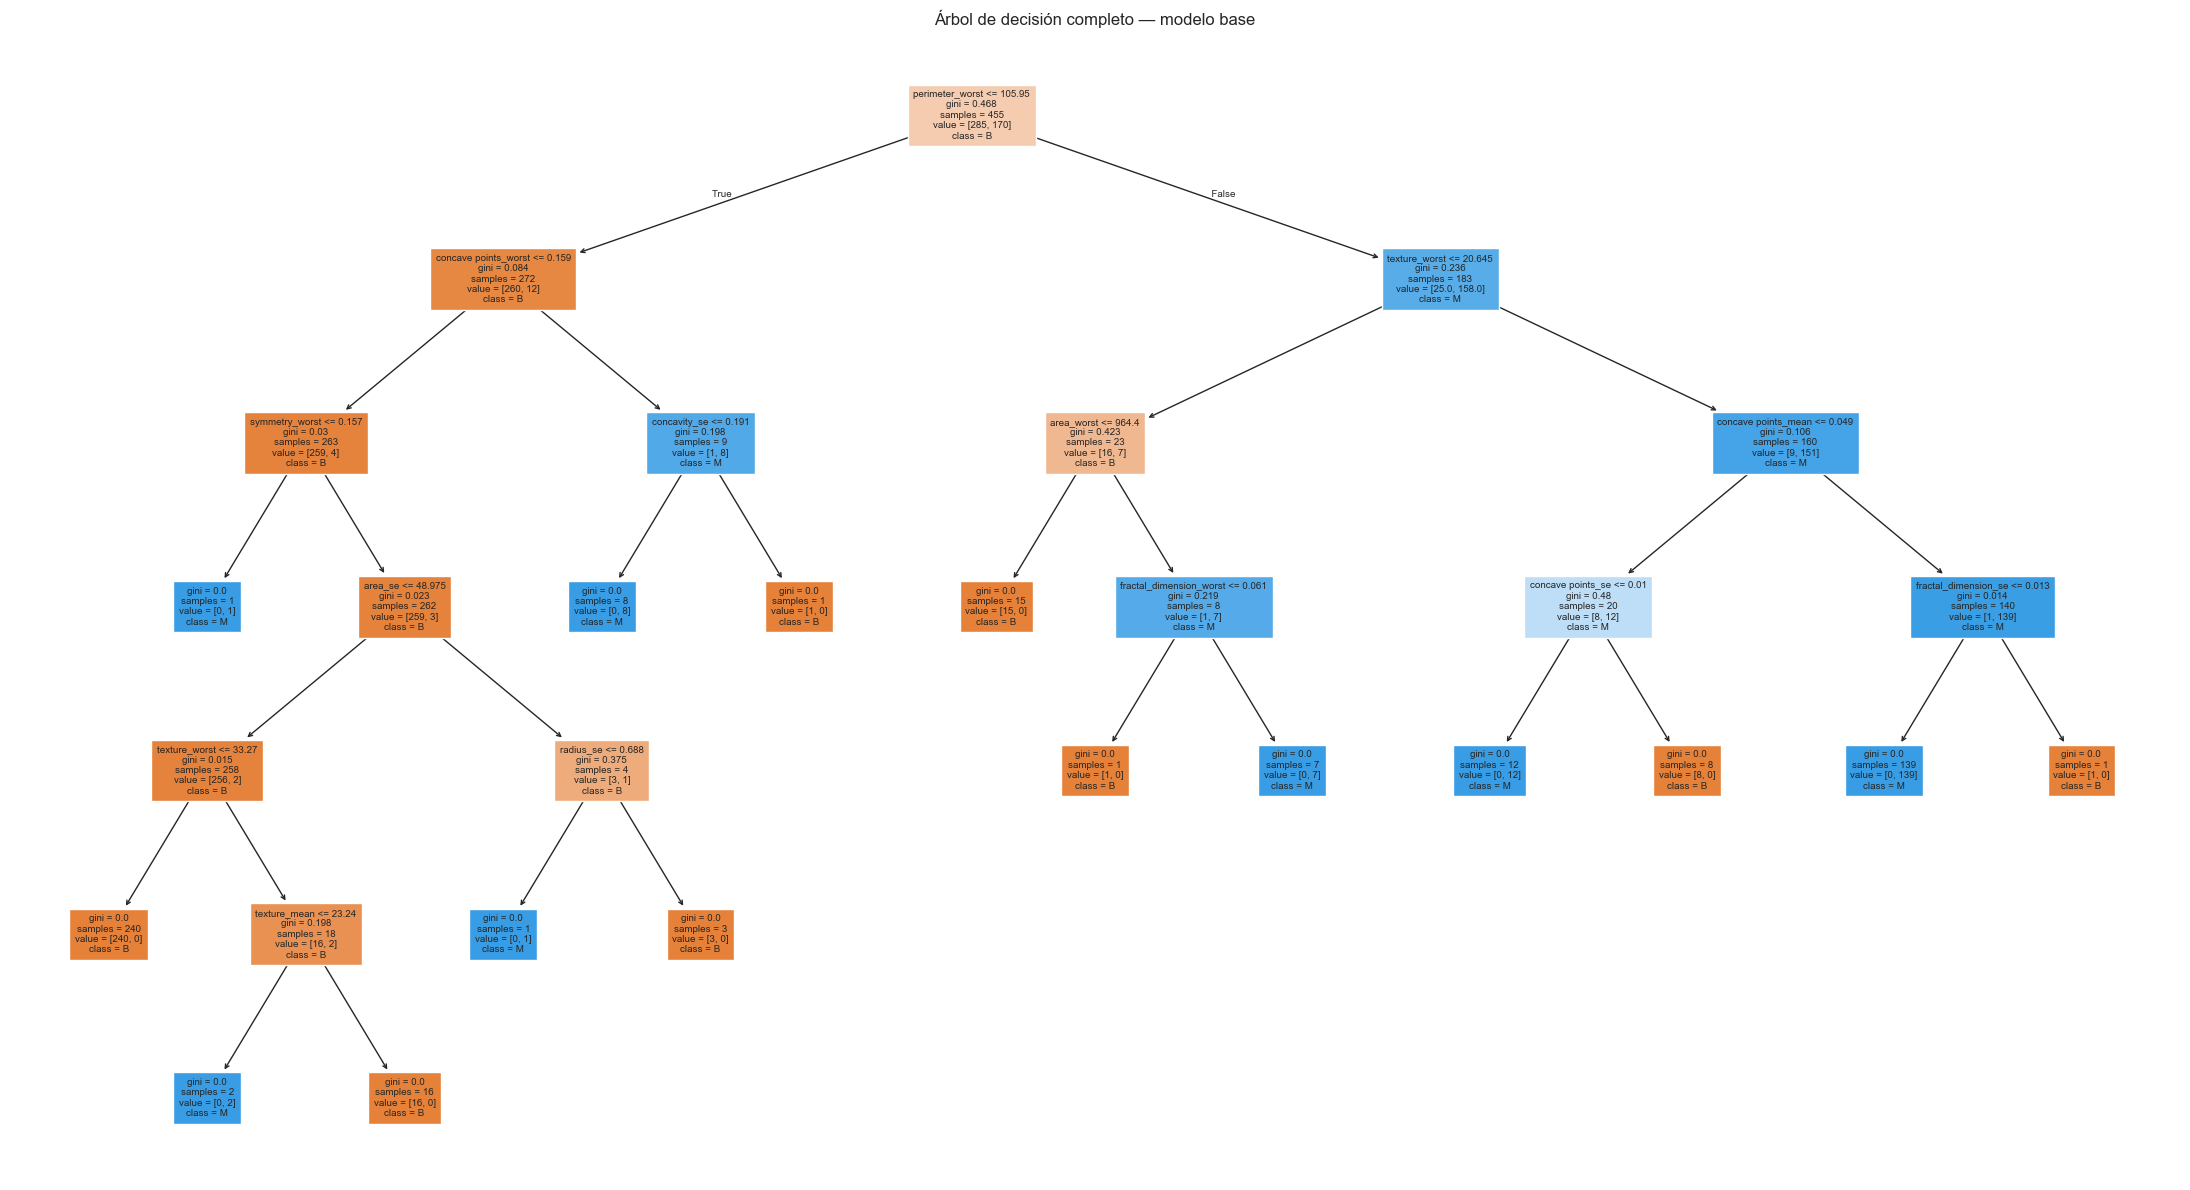

Profundidad del árbol: 6
Número de nodos terminales: 15


In [10]:
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(modelo, filled=True, feature_names=datos.drop(columns=['diagnosis', 'diagnosis_cod']).columns,
          class_names=['B', 'M'], fontsize=7, ax=ax)
plt.title('Árbol de decisión completo — modelo base')
plt.tight_layout()
plt.savefig('grafica_arbol_base.png', dpi=120)
plt.show()
print('Profundidad del árbol:', modelo.get_depth())
print('Número de nodos terminales:', modelo.get_n_leaves())


### Paso 6. Optimización del modelo — búsqueda de hiperparámetros (GridSearchCV)

In [11]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

space = dict()
space['criterion'] = ['gini', 'entropy']
space['max_depth'] = [3, 4, 5, 6, 8, 10]
space['min_samples_leaf'] = [2, 3, 5, 8, 10]
space['min_samples_split'] = [2, 4, 8, 10, 12]

search = GridSearchCV(DecisionTreeClassifier(random_state=1), space, scoring='accuracy', n_jobs=-1, cv=cv)
result = search.fit(X_train, y_train)

print('Mejor puntuación (CV):', result.best_score_)
print('Mejores hiperparámetros:', result.best_params_)


Mejor puntuación (CV): 0.9384702093397747
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 12}


### Paso 7. Reentrenamiento con los mejores hiperparámetros y evaluación final

In [12]:
modelo_opt = DecisionTreeClassifier(random_state=1, **result.best_params_)
modelo_opt.fit(X_train, y_train)
predicciones_opt = modelo_opt.predict(X_test)

print('Exactitud modelo optimizado:', accuracy_score(y_test, predicciones_opt))
print('Precisión:', precision_score(y_test, predicciones_opt))
print('Recall:', recall_score(y_test, predicciones_opt))
print('F1-score:', f1_score(y_test, predicciones_opt))


Exactitud modelo optimizado: 0.9385964912280702
Precisión: 0.926829268292683
Recall: 0.9047619047619048
F1-score: 0.9156626506024096


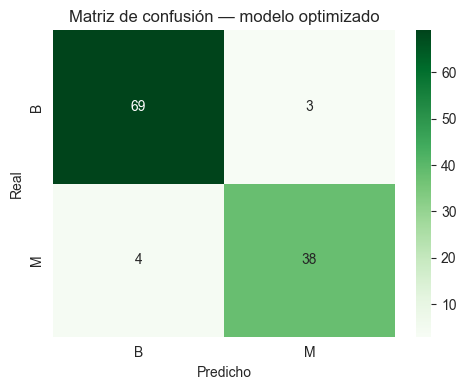

              precision    recall  f1-score   support

           B       0.95      0.96      0.95        72
           M       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [13]:
cm_opt = confusion_matrix(y_test, predicciones_opt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión — modelo optimizado')
plt.tight_layout()
plt.savefig('grafica_matriz_confusion_optimizado.png', dpi=120)
plt.show()

print(classification_report(y_test, predicciones_opt, target_names=['B', 'M']))


### Paso 8. Árbol de decisión completo — modelo optimizado

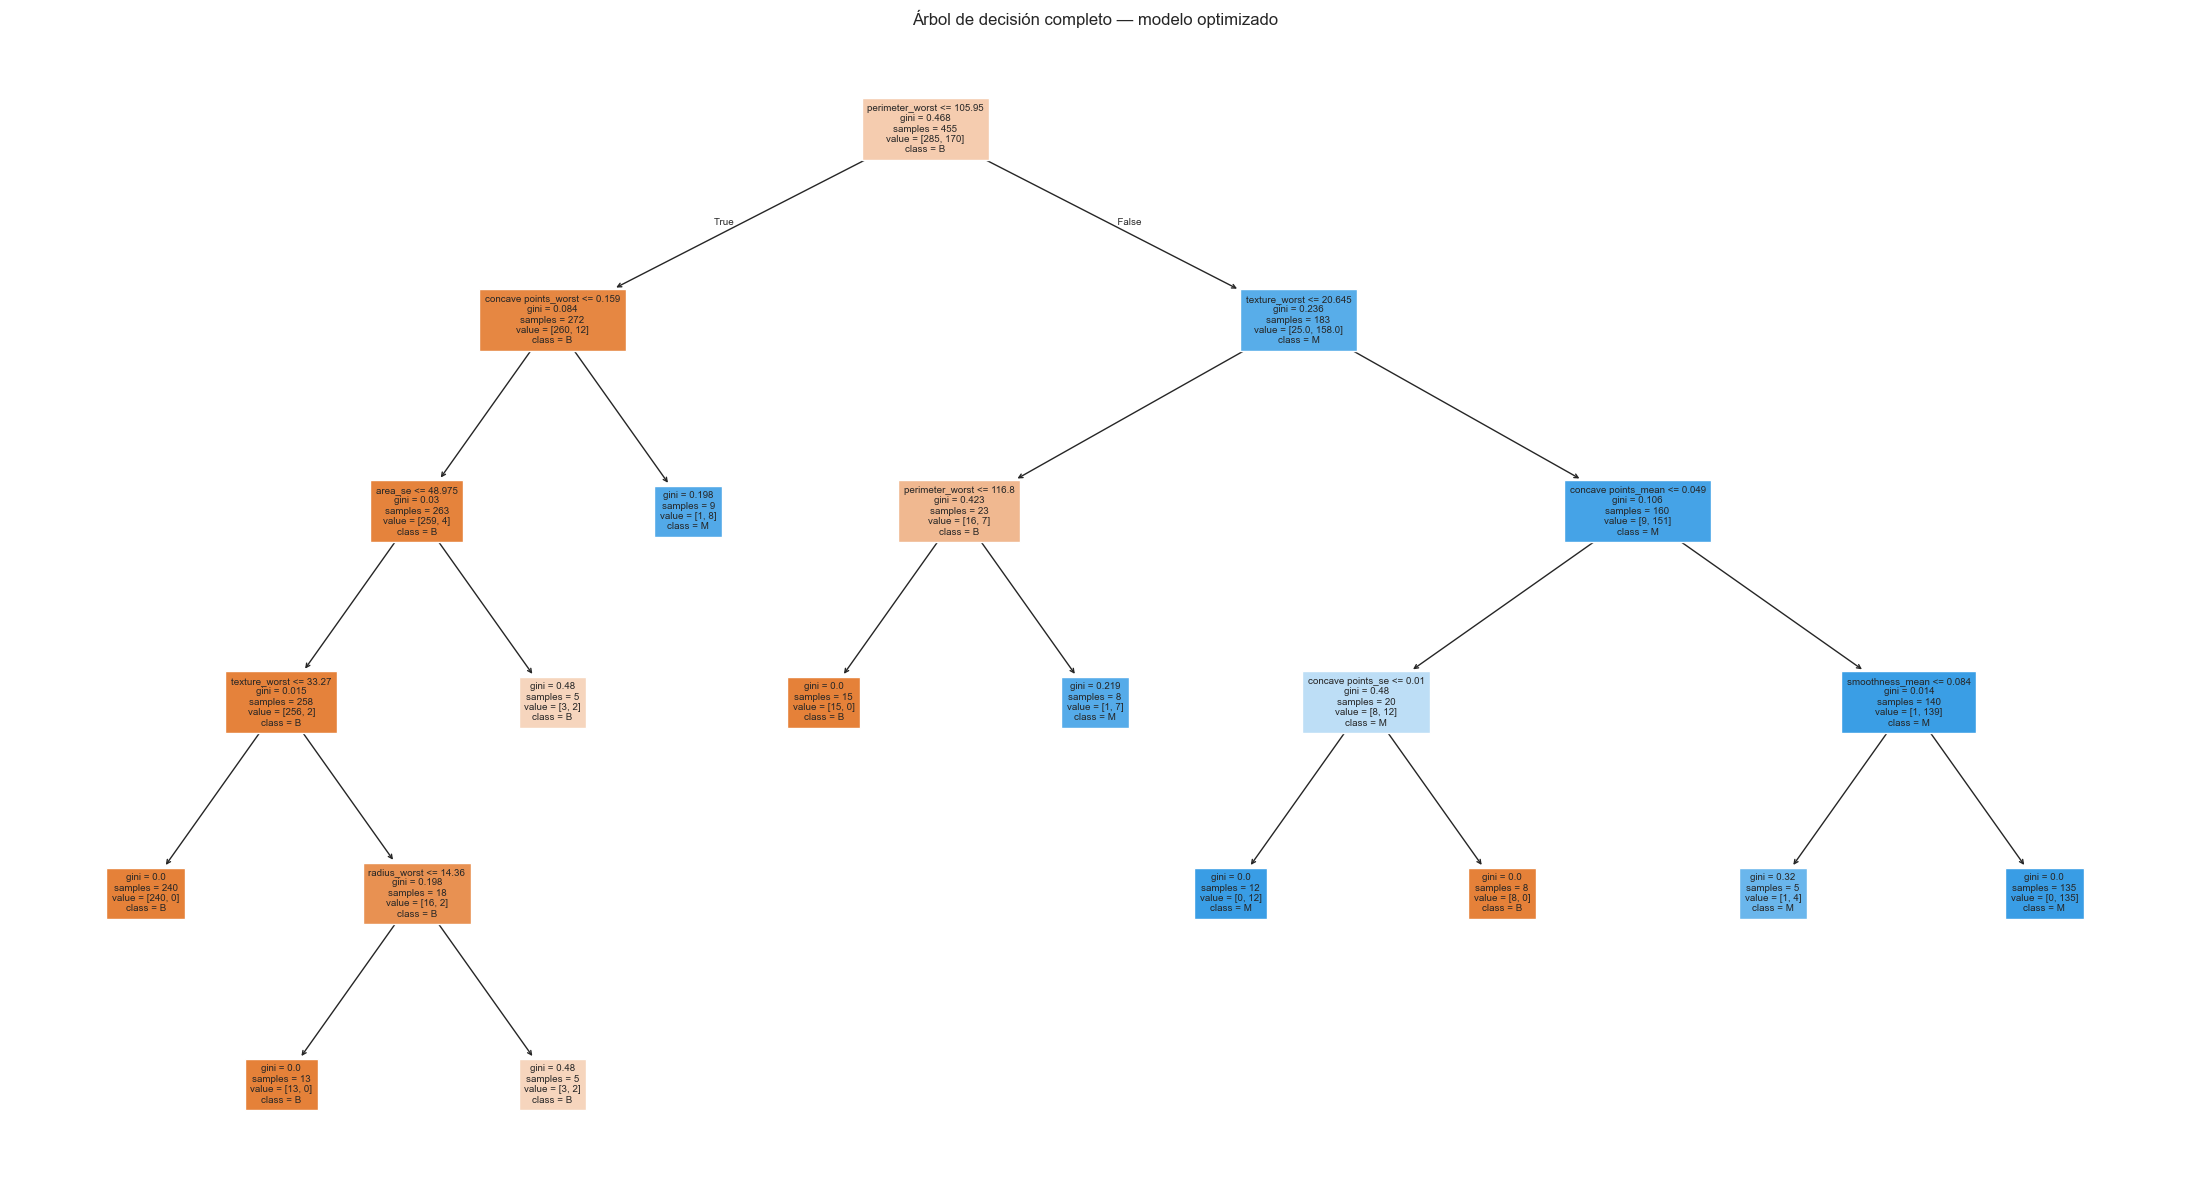

Profundidad del árbol: 5
Número de nodos terminales: 11


In [14]:
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(modelo_opt, filled=True, feature_names=datos.drop(columns=['diagnosis', 'diagnosis_cod']).columns,
          class_names=['B', 'M'], fontsize=7, ax=ax)
plt.title('Árbol de decisión completo — modelo optimizado')
plt.tight_layout()
plt.savefig('grafica_arbol_optimizado.png', dpi=120)
plt.show()
print('Profundidad del árbol:', modelo_opt.get_depth())
print('Número de nodos terminales:', modelo_opt.get_n_leaves())


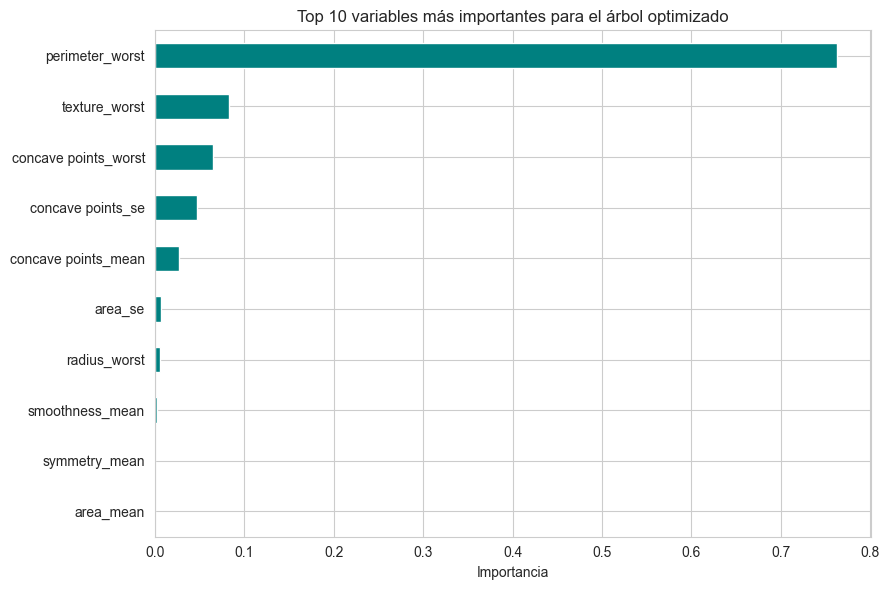

In [15]:
importancias = pd.Series(modelo_opt.feature_importances_,
                          index=datos.drop(columns=['diagnosis', 'diagnosis_cod']).columns)
importancias = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
importancias.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 variables más importantes para el árbol optimizado')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('grafica_importancia_variables.png', dpi=120)
plt.show()


## Conclusión / Interpretación final
El árbol de decisión optimizado mediante `GridSearchCV` mejora (o al menos iguala) la exactitud del modelo
base, reduciendo el sobreajuste al limitar la profundidad y el tamaño mínimo de las hojas. Las variables con
mayor importancia (ver gráfica de barras) son las que más aportan a distinguir tumores malignos de benignos,
lo cual es coherente con la literatura médica sobre este conjunto de datos.

**Enlace al repositorio con el modelo:** https://github.com/YosueCh/2a.-Evaluaci-n-Extracci-n-de-conocimiento-en-bases-de-datos.git
